In [70]:
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import requests

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report

import pickle
import matplotlib.pyplot as plt

In [71]:
# 2. LOAD CROP DATASET (WITH NPK)
df = pd.read_csv("Crop_recommendation.csv")

df.rename(columns={'temperature': 'temp', 'label': 'crop'}, inplace=True)

# soil from NPK
df['soil_type'] = pd.cut(df['N'], bins=3, labels=['sandy','loamy','clay'])

In [ ]:
df

In [72]:
# 3. NASA CLIMATE DATA (RAIPUR)

lat, lon = 21.2514, 81.6296

url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M,PRECTOTCORR,RH2M&community=AG&longitude={lon}&latitude={lat}&start=20200101&end=20221231&format=JSON"

response = requests.get(url).json()
data = response['properties']['parameter']

df_climate = pd.DataFrame({
    'date': list(data['T2M'].keys()),
    'temp': list(data['T2M'].values()),
    'rainfall': list(data['PRECTOTCORR'].values()),
    'humidity': list(data['RH2M'].values())
})

df_climate['date'] = pd.to_datetime(df_climate['date'])

# monthly aggregation
df_climate['month'] = df_climate['date'].dt.to_period('M')
climate_monthly = df_climate.groupby('month').mean().reset_index()

In [73]:
# 4. EXPAND CLIMATE (MATCH SIZE)

climate_expanded = climate_monthly.loc[
    climate_monthly.index.repeat(len(df)//len(climate_monthly) + 1)
].iloc[:len(df)].reset_index(drop=True)

In [74]:
# 5. MERGE ALL DATA

df_final = pd.concat([
    df[['N','P','K','humidity','rainfall','crop']],
    climate_expanded[['temp']]
], axis=1)

df_final['soil_type'] = df['soil_type']

In [75]:
# 6. CLEAN DATA

df_final['soil_type'] = df_final['soil_type'].astype('category').cat.codes
df_final['crop'] = df_final['crop'].astype('category').cat.codes

crop_labels = pd.read_csv("Crop_recommendation.csv")['label'].astype('category').cat.categories

In [76]:
# 7. FEATURES & TARGET

X = df_final[['N','P','K','temp','humidity','rainfall','soil_type']]
y = df_final['crop']

In [77]:
# 8. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [78]:
# 9. SCALING

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
# 10. MODELS

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

lr = LogisticRegression(max_iter=1000)
bag_lr = BaggingClassifier(estimator=lr, n_estimators=10, random_state=42)
bag_lr.fit(X_train, y_train)
lr_pred = bag_lr.predict(X_test)

svm = SVC()
bag_svm = BaggingClassifier(estimator=svm, n_estimators=10, random_state=42)
bag_svm.fit(X_train, y_train)
svm_pred = bag_svm.predict(X_test)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)


In [80]:
# 11. VOTING MODEL

voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200)),
        ('gb', GradientBoostingClassifier()),
        ('lr', LogisticRegression(max_iter=1000))
    ],
    voting='soft'
)

voting.fit(X_train, y_train)
vote_pred = voting.predict(X_test)

In [81]:
# 12. EVALUATION

print("\n===== F1 SCORES =====")
print("RF:", f1_score(y_test, rf_pred, average='weighted'))
print("GB:", f1_score(y_test, gb_pred, average='weighted'))
print("LR Bagging:", f1_score(y_test, lr_pred, average='weighted'))
print("SVM Bagging:", f1_score(y_test, svm_pred, average='weighted'))
print("Voting:", f1_score(y_test, vote_pred, average='weighted'))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, rf_pred))


===== F1 SCORES =====
RF: 0.997725851384388
GB: 0.997725851384388
LR Bagging: 0.9446214342002417
SVM Bagging: 0.9794379710355903
Voting: 0.997725851384388

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        2

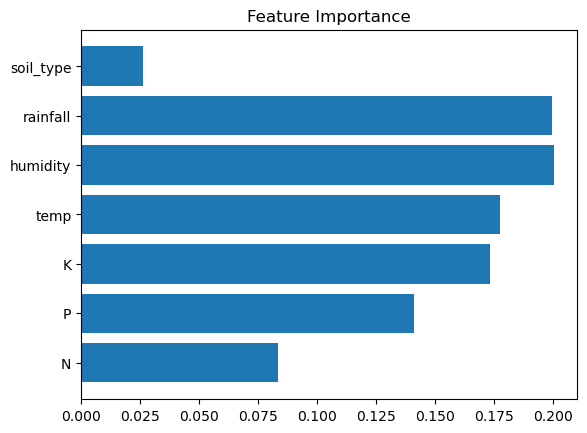

In [82]:
# 13. FEATURE IMPORTANCE

plt.barh(X.columns, rf.feature_importances_)
plt.title("Feature Importance")
plt.show()

In [83]:

# 14. TOP 3 PREDICTION

sample_input = pd.DataFrame([[90, 42, 40, 25, 60, 100, 1]],
                            columns=['N','P','K','temp','humidity','rainfall','soil_type'])

input_scaled = scaler.transform(sample_input)

probs = rf.predict_proba(input_scaled)[0]

top3_idx = np.argsort(probs)[-3:][::-1]

print("\n🌾 Top 3 Crops:")
for i in top3_idx:
    print(crop_labels[i], "→", round(probs[i]*100,2), "%")


🌾 Top 3 Crops:
maize → 37.0 %
coffee → 34.0 %
jute → 14.0 %


In [85]:

# 15. SAVE MODEL

pickle.dump(rf, open("model2.pkl", "wb"))
pickle.dump(scaler, open("scaler2.pkl", "wb"))
pickle.dump(crop_labels, open("labels2.pkl", "wb"))

print("\nModel Saved Successfully")


Model Saved Successfully
